<a href="https://colab.research.google.com/github/Makande340/A02-eda-and-visualization/blob/main/notebook(4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

In [16]:
# Your Phase 1 solution to the problem goes here.
#Q1.1 - Q1.4
#Paper solution uploaded to github repo

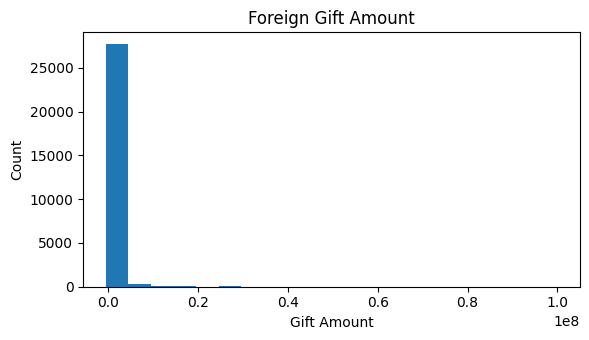

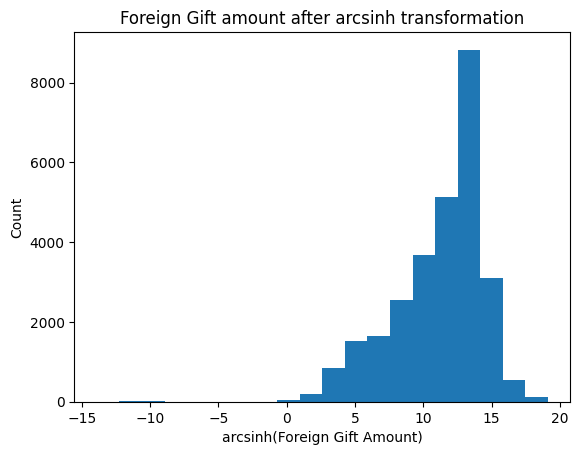

,mean,median,mode,std,min,Q1,Q3,max
0,588232.72,94615.0,100,3222011.43,-537770,5700.0,376142.0,99999999


In [9]:

#Question 2.1
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

url = "./ForeignGifts_edu.csv"
df = pd.read_csv(url)
#Consists of foreign gifts amounts in terms of prices of different gift types from different gift donors found in a variey of countries

#Question 2.2
fig, ax = plt.subplots(figsize=(6, 3.5))
df["Foreign Gift Amount"].hist(bins=20, grid=False, ax=ax)
ax.set(title="Foreign Gift Amount", xlabel="Gift Amount", ylabel="Count")
plt.tight_layout()
plt.show()

df["Foreign Gift Amount_arcsinh"] = np.arcsinh(df["Foreign Gift Amount"])

df["Foreign Gift Amount_arcsinh"].hist(bins=20, grid=False)
plt.title("Foreign Gift amount after arcsinh transformation")
plt.xlabel("arcsinh(Foreign Gift Amount)")
plt.ylabel("Count")
plt.show()


summary = pd.DataFrame({
    "mean": [df["Foreign Gift Amount"].mean()],
    "median": [df["Foreign Gift Amount"].median()],
    "mode": [df["Foreign Gift Amount"].mode().iloc[0]],
    "std": [df["Foreign Gift Amount"].std()],
    "min": [df["Foreign Gift Amount"].min()],
    "Q1": [df["Foreign Gift Amount"].quantile(0.25)],
    "Q3": [df["Foreign Gift Amount"].quantile(0.75)],
    "max": [df["Foreign Gift Amount"].max()],
})
display(summary.round(2))

#Descriptions about variable represented in plot are found within mean, median, and mode describing the overall center of histogram plot. Range from IQR gives more look into the Q3 and Q1 values distribution spread

In [6]:
#Q2.3:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

url = "./ForeignGifts_edu.csv"
df = pd.read_csv(url)

gift_type_counts = df["Gift Type"].value_counts()
gift_type_props = df["Gift Type"].value_counts(normalize=True)

print(gift_type_counts)
print(gift_type_props.round(4))


Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64
Gift Type
Contract         0.6121
Monetary Gift    0.3875
Real Estate      0.0004
Name: proportion, dtype: float64


/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


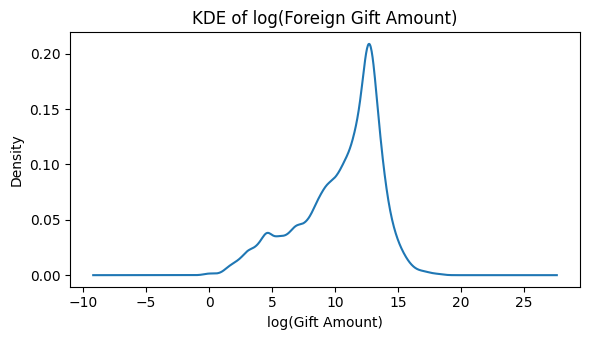

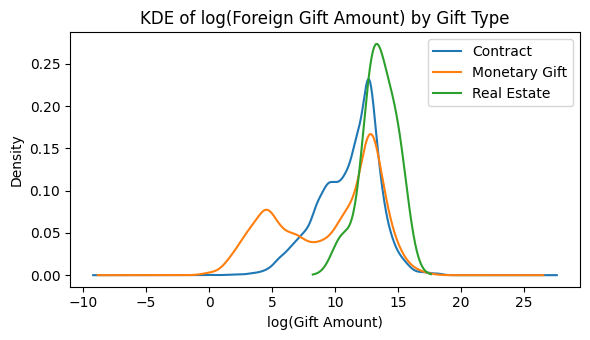

In [9]:
#Q2.4

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

url = "./ForeignGifts_edu.csv"
df = pd.read_csv(url)

df["log_Foreign_Gift_Amount"] = np.log(df["Foreign Gift Amount"])
fig, ax = plt.subplots(figsize=(6, 3.5))
df["log_Foreign_Gift_Amount"].plot.density(ax=ax)
ax.set(title="KDE of log(Foreign Gift Amount)", xlabel="log(Gift Amount)", ylabel="Density")
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(6, 3.5))
for gift_type, group in df.groupby("Gift Type"):
    group["log_Foreign_Gift_Amount"].plot.density(ax=ax, label=gift_type)
ax.set(title="KDE of log(Foreign Gift Amount) by Gift Type", xlabel="log(Gift Amount)", ylabel="Density")
ax.legend()
plt.tight_layout()
plt.show()

#Pattern trend between the gift type amounts show the same overall structure but decreasing concentrations for monetary, contract, and real state being the largest respectively
#as they are clustered around the same amount but at different concentrations. All gift types seem to have there largest concentrations around the same range of gift amounts

In [13]:
#Q2.5

#Top 15 Countries in terms of numbers of gifts:

top_count = df["Country of Giftor"].value_counts().head(15)
print(top_count)


#Top 15 countries in terms of gift amount:

top_amount = df.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(15)
print(top_amount)

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: count, dtype: int64
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64


In [15]:
#Q2.6 -
top_amount = df.groupby("Giftor Name")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(5)
print(top_amount)

#Giftors gifting the largest amount

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
Name: Foreign Gift Amount, dtype: int64


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]